**index:**

**regressions**

1 stock return

2 inflation rate - current consumer price index (CPI) rate return

3 rolling mean and standard deviation


In [2]:
!pip install cufflinks

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.8 MB/s eta 0:00:00


1. stock return

2. inflation rate



In [3]:
# source venv/bin/activate
#pip install yfinance python-dotenv
import os
import pandas as pd
import numpy as np
import datetime
import yfinance as yf
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import cufflinks as cf
import seaborn as sns
import scipy.stats as scs
import statsmodels.api as sm
import scipy.stats as scs
import statsmodels.tsa.api as smt
from plotly.offline import iplot, init_notebook_mode
load_dotenv()

# 1 find stock return
#create dataset
symbol=yf.Ticker('AAPL')
appl_stock_data1=symbol.history(start=datetime.datetime(2025,12,1), end=datetime.datetime(2025,12,31))
a1=[]
for x,y in appl_stock_data1['Close'].items():
    a1.append({'date':pd.Timestamp(x).strftime('%Y-%m-%d'),'value':y})
for i, x in enumerate(a1):
    if i==0:
        x['return']='NaN'
    else:
        x['return']=(a1[i]['value']-a1[i-1]['value'])/a1[i-1]['value']
print('1. find stock return')
for x in a1:
    print(x)

# 2 find stock return with Inflation rate - current consumer price index (CPI) rate
# create dataset
appl_stock_data2=symbol.history(interval='1mo',start=datetime.datetime(2025, 1, 1), end=datetime.datetime(2025, 12, 31))
a2=[]
us_cpi=[
    {'date':'2025-01-01','cpi':313.67},
    {'date':'2025-02-01','cpi':319.082},
    {'date':'2025-03-01','cpi':319.799},
    {'date':'2025-04-01','cpi':320.795},
    {'date':'2025-05-01','cpi':314.07},
    {'date':'2025-06-01','cpi':322.56},
    {'date':'2025-07-01','cpi':323.05},
    {'date':'2025-08-01','cpi':323.98},
    {'date':'2025-09-01','cpi':324.8},
    {'date':'2025-10-01','cpi':0},
    {'date':'2025-11-01','cpi':324.12},
    {'date':'2025-12-01','cpi':0},
]
for x,y in appl_stock_data2['Close'].items():
    a2.append({'date':pd.Timestamp(x).strftime('%Y-%m-%d'),'value':y})
for i, x in enumerate(a2):
    x['us_cpi']=us_cpi[i]['cpi']
for i, x in enumerate(a2):
    if i==0:
        x['inflation_rate']='NaN'
    elif a2[i]['us_cpi']==0:
        x['inflation_rate']='NaN'
    elif a2[i-1]['us_cpi']==0:
        x['inflation_rate']='NaN'
    else:
        x['inflation_rate']=(a2[i]['us_cpi']-a2[i-1]['us_cpi'])/a2[i-1]['us_cpi']
for i, x in enumerate(a2):
    if i==0:
        x['simple_rtn']='NaN'
    else:
        x['simple_rtn']=(a2[i]['value']-a2[i-1]['value'])/a2[i-1]['value']
for i, x in enumerate(a2):
    if x['inflation_rate']=='NaN':
        x['real_rtn']='NaN'
    elif x['simple_rtn']=='NaN':
        x['real_rtn']='NaN'
    else:
        x['real_rtn']=(x['simple_rtn']+1)/(x['inflation_rate']+1)-1
print('\n2. find stock return with Inflation rate - current consumer price index (CPI) rate')
for x in a2:
    print(x)


1. find stock return
{'date': '2025-12-01', 'value': 283.1000061035156, 'return': 'NaN'}
{'date': '2025-12-02', 'value': 286.19000244140625, 'return': 0.01091485789922861}
{'date': '2025-12-03', 'value': 284.1499938964844, 'return': -0.007128161457490258}
{'date': '2025-12-04', 'value': 280.70001220703125, 'return': -0.012141410394363587}
{'date': '2025-12-05', 'value': 278.7799987792969, 'return': -0.00684009028940926}
{'date': '2025-12-08', 'value': 277.8900146484375, 'return': -0.003192424617104447}
{'date': '2025-12-09', 'value': 277.17999267578125, 'return': -0.0025550467279456175}
{'date': '2025-12-10', 'value': 278.7799987792969, 'return': 0.005772444425262539}
{'date': '2025-12-11', 'value': 278.0299987792969, 'return': -0.0026902934331158963}
{'date': '2025-12-12', 'value': 278.2799987792969, 'return': 0.0008991835452923648}
{'date': '2025-12-15', 'value': 274.1099853515625, 'return': -0.01498495560596003}
{'date': '2025-12-16', 'value': 274.6099853515625, 'return': 0.00182408

/tmp/ipython-input-1645004753.py:14: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning:

The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)



AAPL (1)trading frequency in 10y(2015-2025)


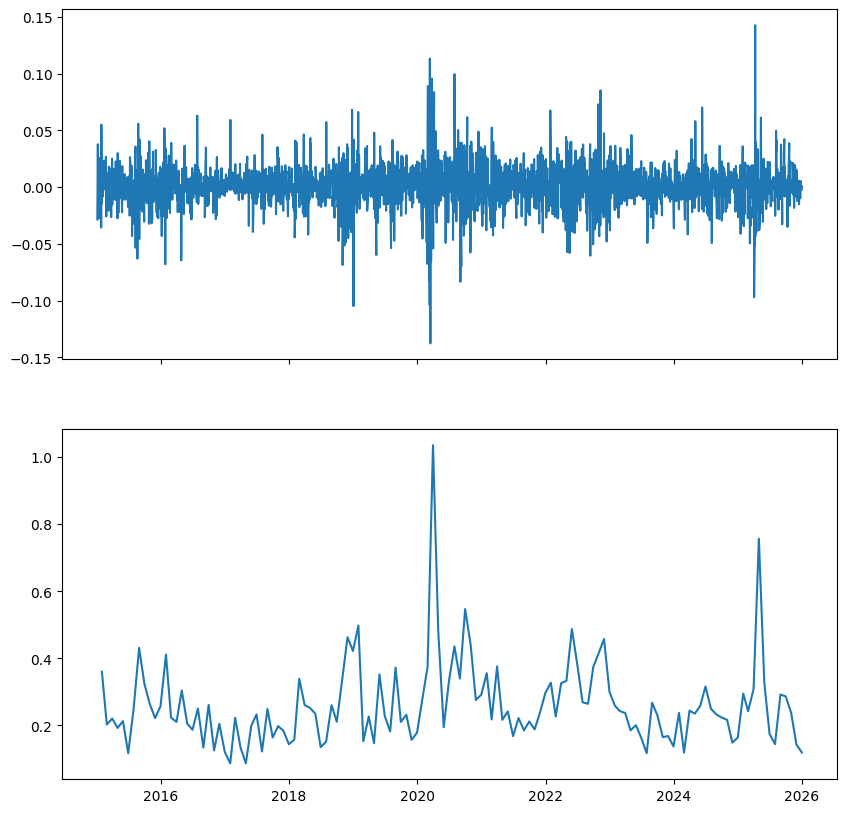

AAPL (2)stock price($) frequency, (3)simple returns(%) frequency, (4)log returns(%) frequency


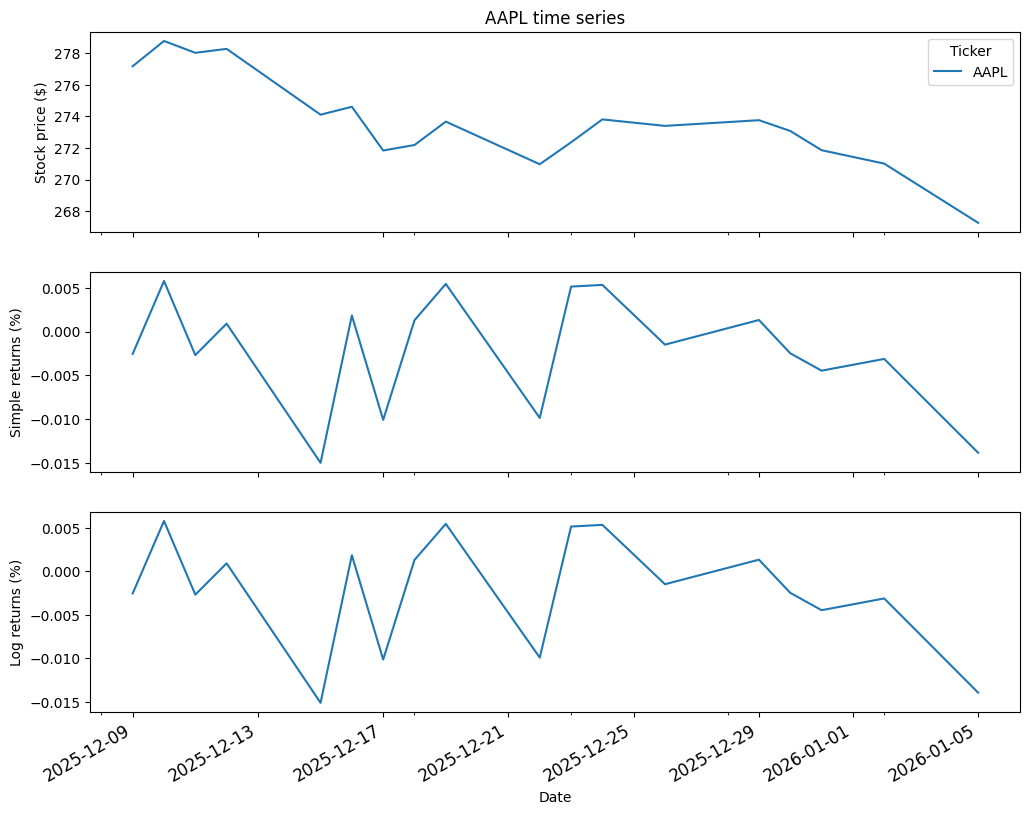

In [31]:
# Trading frequency
# if frequency is dinamic, it called High-frequency trading (HFT), active trading and expected high returns
#create dataset
a3=yf.download('AAPL',start='2015-01-01',end='2025-12-31',auto_adjust=False,progress=False)
a3=a3.loc[:,['Adj Close']]
a3.rename(columns={'Adj Close':'value'},inplace=True)
# print('data set1 (value) \n',a3)
a3['log_rtn']= np.log(a3.value/a3.value.shift(1))
a3.drop('value',axis=1,inplace=True)
a3.dropna(axis=0,inplace=True)
a3.head()
def realized_volatility(x):
    return np.sqrt(np.sum(x**2))
a4=a3.groupby(pd.Grouper(freq='M')).apply(realized_volatility)
a4.rename(columns={'log_rtn':'return1'},inplace=True)
a4.return1=a4.return1*np.sqrt(12)
# print('data set2 (return calculated by volatility)\n',a4)
fig,ax=plt.subplots(2,1,sharex=True,figsize=(10,10))
ax[0].plot(a3)
ax[1].plot(a4)
print('AAPL (1)trading frequency in 10y(2015-2025)')
plt.show()
print('AAPL (2)stock price($) frequency, (3)simple returns(%) frequency, (4)log returns(%) frequency')
a5 = yf.download('AAPL', auto_adjust = False, progress=False)
a5 = a5.loc[:, ['Adj Close']]
a5.rename(columns={'Adj Close': 'value'}, inplace=True)
a5['simple_rtn'] = a5.value.pct_change()
a5['log_rtn'] = np.log(a5.value / a5.value.shift(1))
a5.dropna(how = 'any', inplace = True)
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
a5.value.plot(ax=ax[0])
ax[0].set(title = 'AAPL time series',
         ylabel = 'Stock price ($)')
a5.simple_rtn.plot(ax=ax[1])
ax[1].set(ylabel = 'Simple returns (%)')
a5.log_rtn.plot(ax=ax[2])
ax[2].set(xlabel = 'Date',
         ylabel = 'Log returns (%)')
ax[2].tick_params(axis='x',
                 which='major',
                 labelsize=12)
plt.show()

In [ ]:
# x
init_notebook_mode()
cf.set_config_file(world_readable=True, theme='pearl',offline=True)
a5.iplot(subplots=True, shape=(3,1), shared_xaxes=True, title='AAPL time series')


Output hidden; open in https://colab.research.google.com to view.

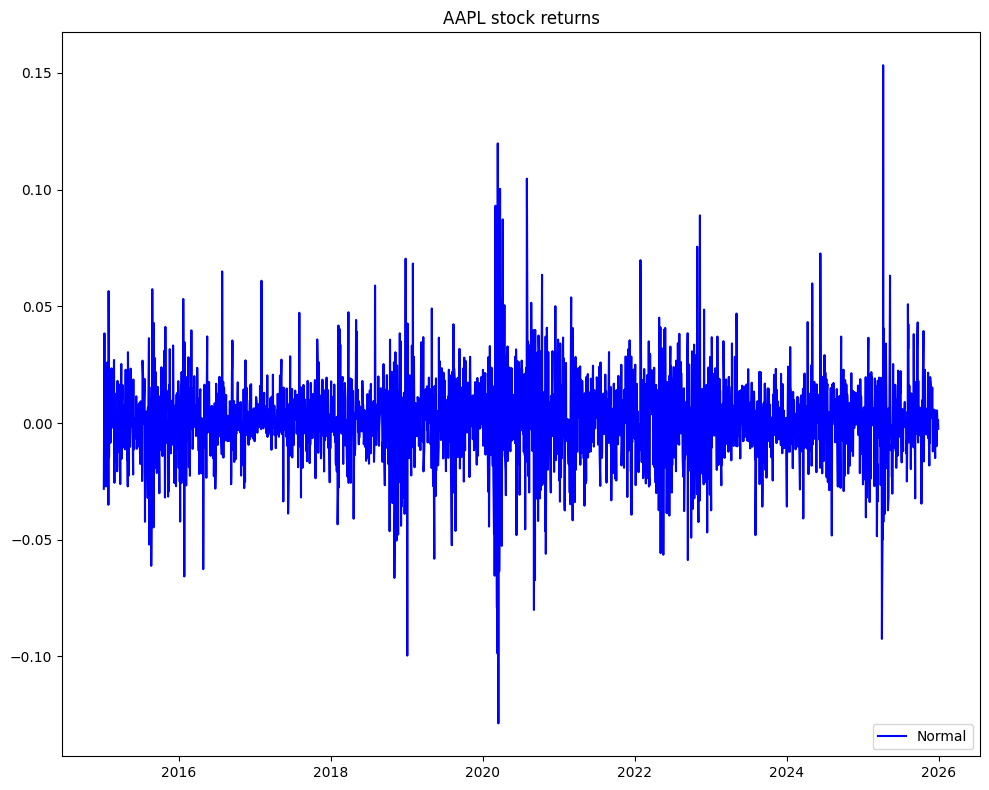

In [9]:
import matplotlib.pyplot as plt
import numpy as np
x1=[0,1,1,2,3,4,5,6,7,7,8]
y1=[55,60,65,62,68,70,75,78,82,85,87]
# x2=[0,1,1,2,3,4,5,6,7,7,8]
# y2=[50,58,65,70,78,67,70,78,82,85,80]
# x1=np.array([0,1,1,2,3,4,5,6,7,7,8])
# y1=np.array([55,60,65,62,68,70,75,78,82,85,87])
# x2=np.array([0,1,1,2,3,4,5,6,7,7,8])
# y2=np.array([50,58,65,70,78,67,70,78,82,85,80])
# plt.scatter(x1,y1,color='skyblue',alpha=.8,s=4)
# plt.scatter(x2,y2,color='pink',alpha=.8,s=4)
# plt.title('Scatter Practice')
# plt.xlabel('Studied Hour')
# plt.ylabel('Result')
# plt.show()

# 1 create dataset
a6=yf.download('AAPL',start='2015-01-01',end='2025-12-31',auto_adjust=False,progress=False)
a6=a6.loc[:,['Adj Close']]
a6.rename(columns={'Adj Close':'value'}, inplace=True)
a6['return1']=a6.value.pct_change()
# print('a6',a6)
# dataset2 circle marker list by mean, std
a7=a6['return1'].rolling(window=21).agg(['mean','std'])
#---part I can not do [start]-----
def circle_marker(x,y,n_sigmas=3):
  return x['return1']
  # if (x['return']>y['mean']+3*y['std'])|(x['return']<y['mean']-3*y['std']):
  #     return 1
  # else:
  #     return 0
# print('value\n',a6['return'])
# print('mean\n',a7['mean'])
# print('std\n',a7['std'])
#---part I can not do [end]-----
# print('circle marker:',circle_marker(a6,a7))

fig, ax=plt.subplots(figsize=(10,8))
ax.plot(a6.index, a6.return1, color='blue', label='Normal')
# ax.scatter(x1,y1,color='skyblue',alpha=.8,s=4)
# ax.circle_marker(a8.index,a8.return,color='red',label='Anomaly')
ax.set_title('AAPL stock returns')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()



a8 dataset value:                  value   return1                    
                  AAPL                mean       std
Date                                                
2015-01-02   24.237547       NaN       NaN       NaN
2015-01-05   23.554733 -0.028172       NaN       NaN
2015-01-06   23.556955  0.000094       NaN       NaN
2015-01-07   23.887278  0.014022       NaN       NaN
2015-01-08   24.805079  0.038422       NaN       NaN
...                ...       ...       ...       ...
2025-12-23  272.359985  0.005130  0.000187  0.008501
2025-12-24  273.809998  0.005324 -0.000337  0.007765
2025-12-26  273.399994 -0.001497 -0.000589  0.007709
2025-12-29  273.760010  0.001317 -0.000626  0.007698
2025-12-30  273.079987 -0.002484 -0.000968  0.007609

[2765 rows x 4 columns]
a8 dataset columns: MultiIndex([(  'value', 'AAPL'),
            ('return1',     ''),
            (       '', 'mean'),
            (       '',  'std')],
           )
a8 dataset return1 mean:              return1
   

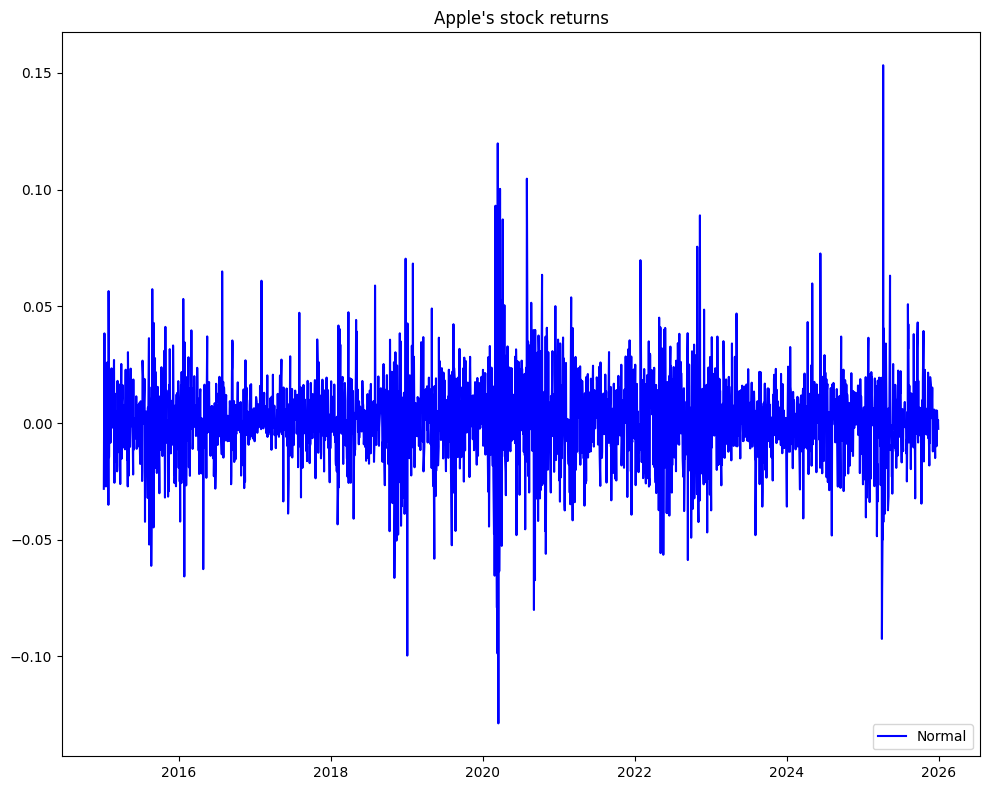

In [30]:
a6=yf.download('AAPL',start='2015-01-01',end='2025-12-31',auto_adjust=False,progress=False)
a6=a6.loc[:,['Adj Close']]
a6.rename(columns={'Adj Close':'value'}, inplace=True)
a6['return1']=a6.value.pct_change()
# print(a6.head())
a7=a6[['return1']].rolling(window=21).agg(['mean','std'])
a7.columns = a7.columns.droplevel()
# print('a7:',a7.columns)
a8=a6.join(a7)
print('a8 dataset value:',a8)
print('a8 dataset columns:',a8.columns)
print('a8 dataset return1 mean:',a8[['return1']])
# print('a8 dataset return:',a8[['']])
# def circle_marker(x,n_sigmas=3):
#   print('mean',x['mean'])
#   return
  # if (x['return1']>x['mean']+3*x['std'])|(x['return1']<x['mean']-3*x['std']):
  # The number of standard deviations above/below the mean - used for detecting outliers
  #     return 1
  # else:
  #     return 0
# def function1(x):
#   return x+1
# df=pd.DataFrame({'x':[50,40,30],'y':[300,1112,42]})
# x=df.apply(function1)
# print('mean:',a8['stv'])
# print(circle_marker(a8))
# print(a8.apply(circle_marker,axis=1))
# a8['outlier']=a8.apply(function1,axis=1)
# outliers=a8.loc[a8['outlier']== 1,['return1']]
# print('a8 index x:',a8.index)
# print('\na8 return y:',a8.return1)

fig, ax=plt.subplots(figsize=(10,8))
ax.plot(a8.index, a8.return1, color='blue', label='Normal')
# ax.circle_marker(a8.index,a8.return1,color='red',label='Anomaly')
ax.set_title("Apple's stock returns")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

Practice

standard dev of 1,2,4: 1.5275252316519468
avr: [-1.3333333333333335, -0.3333333333333335, 1.6666666666666665]
mean: 5.0
    x     y
0  51   301
1  41  1113
2  31    43
index        Rate    Quantity
0  0.001425  537.277135
1  0.001429    6.591747


<Axes: xlabel='Quantity'>

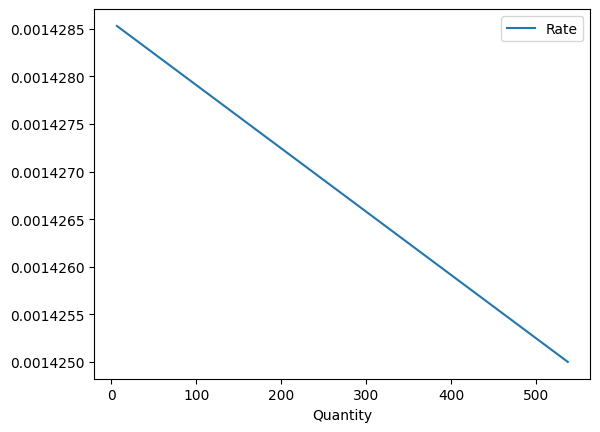

In [29]:
import statistics
print('standard dev of 1,2,4:',statistics.stdev([1,2,4]))# sample1 stdev res:1.52
avr = sum([1,2,4]) / len([1,2,4]) # statistics.mean([1,2,4])
x2=[]
for x1 in [1,2,4]:
    x2.append(x1-avr)
print('avr:',x2)# sample2 dev with stev of 1 res:[-1.3333333333333335, -0.3333333333333335, 1.6666666666666665]

print('mean:',(1 + 3 + 5 + 7 + 9) /5)

def function1(x):
  return x+1
df=pd.DataFrame({'x':[50,40,30],'y':[300,1112,42]})
x=df.apply(function1)
print(x)
d={"sell":[{"Rate": 0.001425,"Quantity": 537.27713514},{"Rate": 0.00142853,"Quantity": 6.59174681}
]}
df=pd.DataFrame(d['sell'])
print('index',df)
df.plot(x='Quantity',y='Rate')

# import matplotlib.pyplot as plt
# import numpy as np
# # x1=[0,1,1,2,3,4,5,6,7,7,8]
# # y1=[55,60,65,62,68,70,75,78,82,85,87]
# # x2=[0,1,1,2,3,4,5,6,7,7,8]
# # y2=[50,58,65,70,78,67,70,78,82,85,80]
# x1=np.array([0,1,1,2,3,4,5,6,7,7,8])
# y1=np.array([55,60,65,62,68,70,75,78,82,85,87])
# x2=np.array([0,1,1,2,3,4,5,6,7,7,8])
# y2=np.array([50,58,65,70,78,67,70,78,82,85,80])
# plt.scatter(x1,y1,color='skyblue',alpha=.8,s=2)
# plt.scatter(x2,y2,color='pink',alpha=.8,s=2)
# plt.title('Scatter Practice')
# plt.xlabel('Studied Hour')
# plt.ylabel('Result')
# plt.show()

/tmp/ipython-input-2076752318.py:1: FutureWarning:

YF.download() has changed argument auto_adjust default to True

/tmp/ipython-input-2076752318.py:11: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
1985-01-02   165.369995   167.199997   165.190002   167.199997    67820000
1985-01-03   164.570007   166.110001   164.380005   165.369995    88880000
1985-01-04   163.679993   164.550003   163.360001   164.550003    77480000
1985-01-07   164.240005   164.710007   163.679993   163.679993    86190000
1985-01-08   163.990005   164.589996   163.910004   164.240005    92110000
...                 ...          ...          ...          ...         ...
2018-12-21  2416.620117  2504.409912  2408.550049  2465.379883  7657890000
2018-12-24  2351.100098  2410.340088  2351.100098  2400.560059  2613670000
2018-12-26  2467.699951  2467.760010  2346.580078  2363.120117  4249740000
2018-12-27  2488.830078  2489.100098  2397.939941  2442.500000  4139010000
2018-12-28  2485.739990  

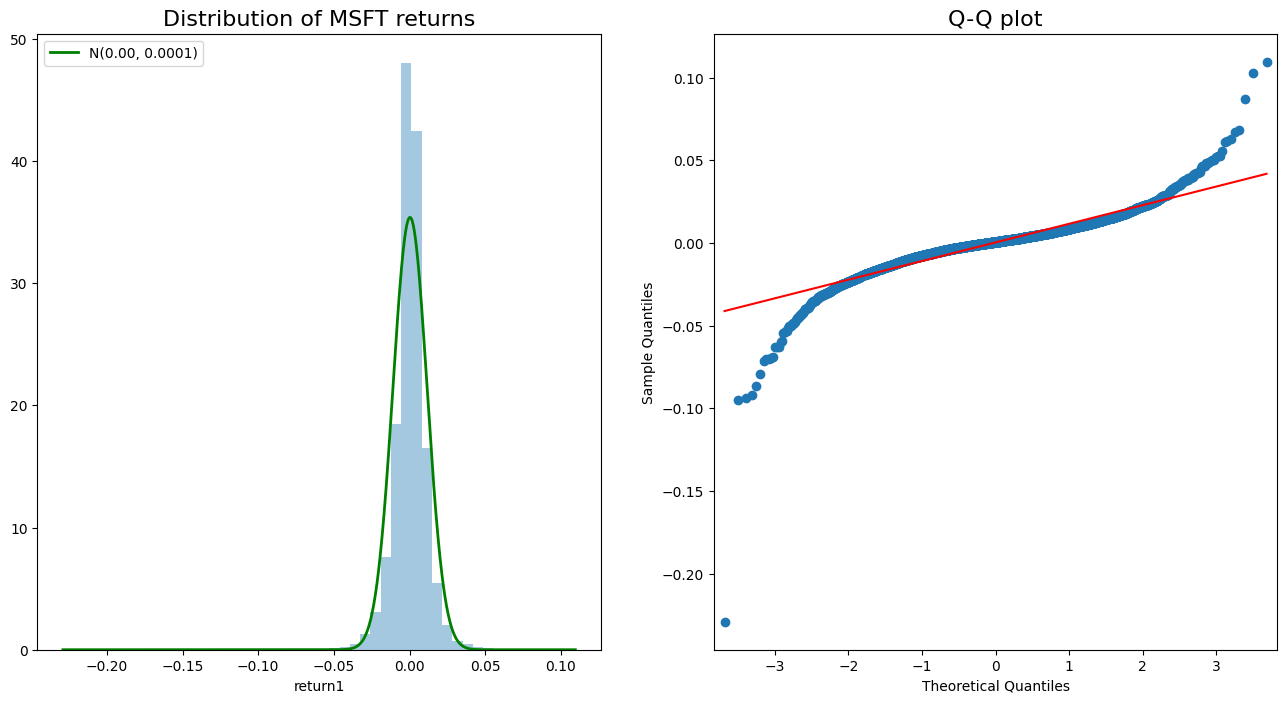

In [ ]:
df=yf.download('^GSPC',start='1985-01-01',end='2018-12-31',progress=False)
print(df)
df=df[['Close']].rename(columns={'Close': 'value'})
df['return1'] = np.log(df.value/df.value.shift(1))
df=df[['value','return1']].dropna(how='any')
r_range=np.linspace(min(df.return1), max(df.return1), num=1000)
mu=df.return1.mean()
sigma=df.return1.std()
norm_pdf=scs.norm.pdf(r_range,loc=mu,scale=sigma)
fig,ax=plt.subplots(1, 2, figsize=(16, 8))
sns.distplot(df.return1, kde=False, norm_hist=True, ax=ax[0])
ax[0].set_title('Distribution of MSFT returns', fontsize=16)
ax[0].plot(r_range, norm_pdf, 'g', lw=2,
          label=f'N({mu:.2f}, {sigma**2:.4f})')
ax[0].legend(loc='upper left');
qq = sm.qqplot(df.return1.values, line='s', ax=ax[1])
ax[1].set_title('Q-Q plot', fontsize = 16)
plt.show()

In [ ]:
jb_test = scs.jarque_bera(df.return1.values)
print('---------- Summary of Statistics ----------')
print('Range of dates:', min(df.index.date), '-', max(df.index.date))
print('Number of observations:', df.shape[0])
print(f'Mean: {df.return1.mean():.4f}')
print(f'Median: {df.return1.median():.4f}')
print(f'Min: {df.return1.min():.4f}')
print(f'Max: {df.return1.max():.4f}')
print(f'Standard Deviation: {df.return1.std():.4f}')
print(f'Skewness: {df.return1.skew():.4f}')
print(f'Kurtosis: {df.return1.kurtosis():.4f}')
print(f'Jarque-Bera statistic: {jb_test[0]:.2f} with p-value: {jb_test[1]:.2f}')
print('----------------------------------------------')

---------- Summary of Statistics ----------
Range of dates: 1985-01-03 - 2018-12-28
Number of observations: 8568
Mean: 0.0003
Median: 0.0006
Min: -0.2290
Max: 0.1096
Standard Deviation: 0.0113
Skewness: -1.2628
Kurtosis: 28.0156
Jarque-Bera statistic: 282134.38 with p-value: 0.00
----------------------------------------------


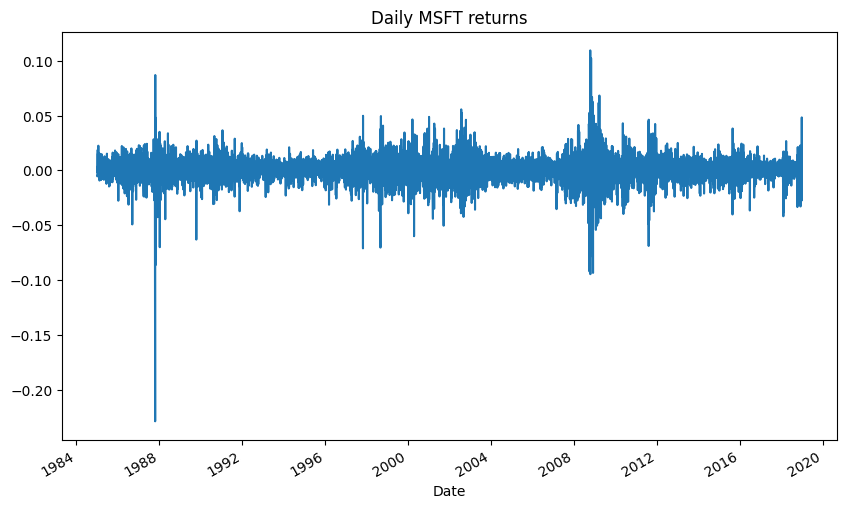

In [ ]:
df.return1.plot(title='Daily MSFT returns', figsize=(10,6))
plt.show()

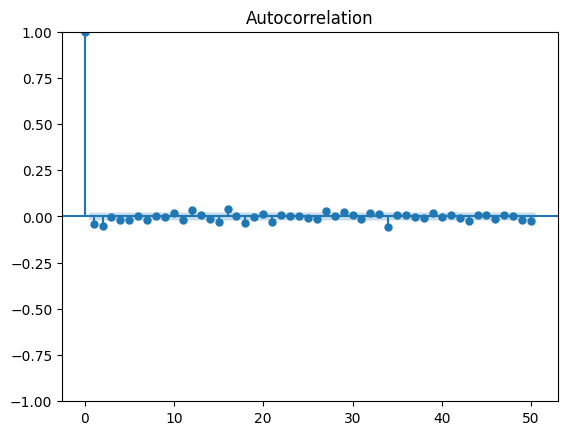

In [ ]:
N_LAGS=50
SIGNIFICANCE_LEVEL=0.05
acf=smt.graphics.plot_acf(df.return1,lags=N_LAGS,alpha=SIGNIFICANCE_LEVEL)
plt.show()

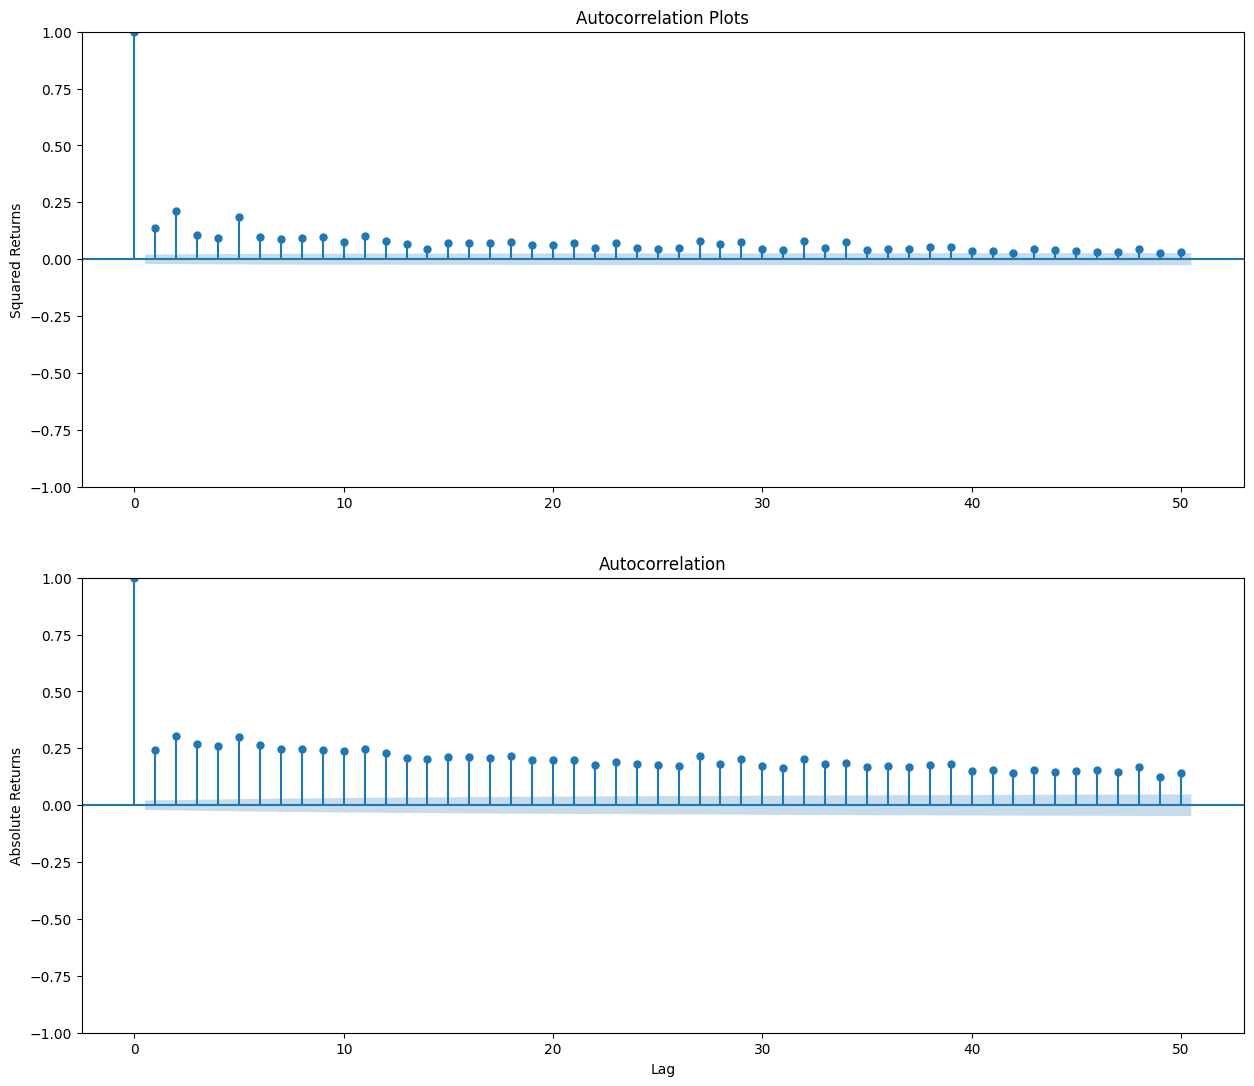

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(15, 13))
smt.graphics.plot_acf(df.return1 ** 2, lags=N_LAGS,
                     alpha=SIGNIFICANCE_LEVEL, ax = ax[0])
ax[0].set(title='Autocorrelation Plots',ylabel='Squared Returns')
smt.graphics.plot_acf(np.abs(df.return1), lags=N_LAGS, alpha=SIGNIFICANCE_LEVEL, ax = ax[1])
ax[1].set(ylabel='Absolute Returns',xlabel='Lag')
# plt.tight_layout()
plt.show()

In [ ]:
df['moving_std_252'] = df[['return1']].rolling(window=252).std()
df['moving_std_21'] = df[['return1']].rolling(window=21).std()